# Society of Mind

In [ ]:
print("\n🏗️  Society of Mind Architecture:")
print("""
    ┌─────────────────────────────────────-┐
    │        Society of Mind Agent         │
    │  ┌─────────────────────────────────┐ │
    │  │         Inner Team              │ │
    │  │  ┌─────────┐  ┌─────────────┐   │ │
    │  │  │ Agent A │  │   Agent B   │   │ │
    │  │  │(Writer) │  │  (Editor)   │   │ │
    │  │  └─────────┘  └─────────────┘   │ │
    │  │         │            │          │ │
    │  │         └────┬───────┘          │ │
    │  │              │                  │ │
    │  │         Discussion              │ │
    │  └─────────────────────────────────┘ │
    │                 │                    │
    │            Synthesis                 │
    │                 │                    │
    │           Final Response             │
    └─────────────────────────────────────-┘
    """)

#### Reference URL
https://microsoft.github.io/autogen/stable//reference/python/autogen_agentchat.agents.html#autogen_agentchat.agents.SocietyOfMindAgent

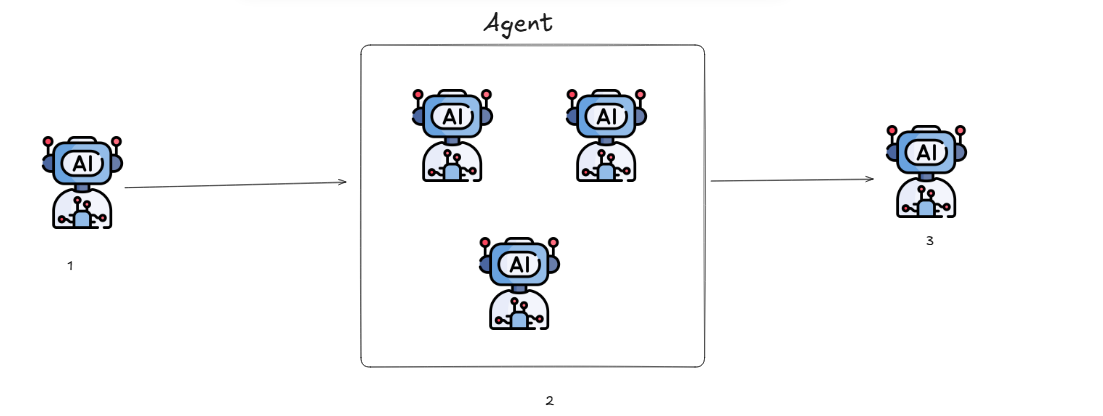 <br><br> 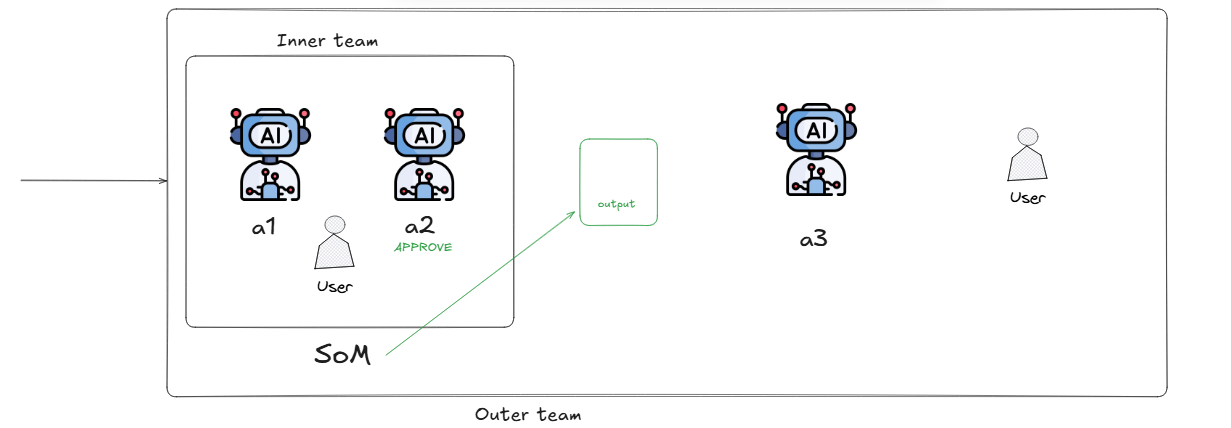
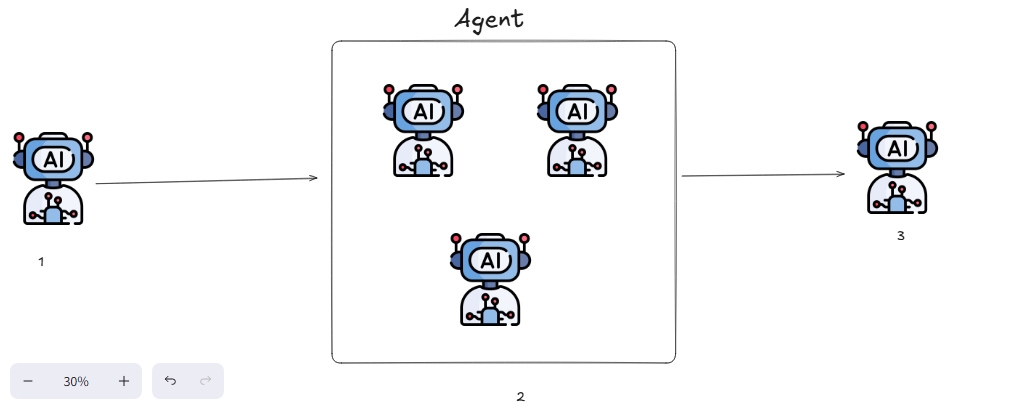

In [1]:
import asyncio
from autogen_agentchat.ui import Console
from autogen_agentchat.agents import AssistantAgent, SocietyOfMindAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination

In [2]:
import os
from dotenv import load_dotenv

# Load API Key
load_dotenv()

api_key= os.getenv("OPENAI_API_KEY")

In [3]:
# Model Client

model_client= OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)

model_client

#### Assistant Agent-1

In [4]:
agent1= AssistantAgent(
    name="assistant1", 
    model_client=model_client, 
    system_message="You are a writer, write well under 50 words."
)

#### Assistant Agent-2

In [5]:
agent2= AssistantAgent(
        "assistant2",
        model_client=model_client,
        system_message="You are an editor, provide critical feedback under 50 words. Respond with 'APPROVE' if the text addresses all feedbacks."
    )

#### Inner Termination

In [6]:
inner_termination= TextMentionTermination("APPROVE")

#### Roun Robin Group Chat (Inner Team)

In [8]:
inner_team= RoundRobinGroupChat(
    [agent1, agent2], 
    termination_condition=inner_termination
)

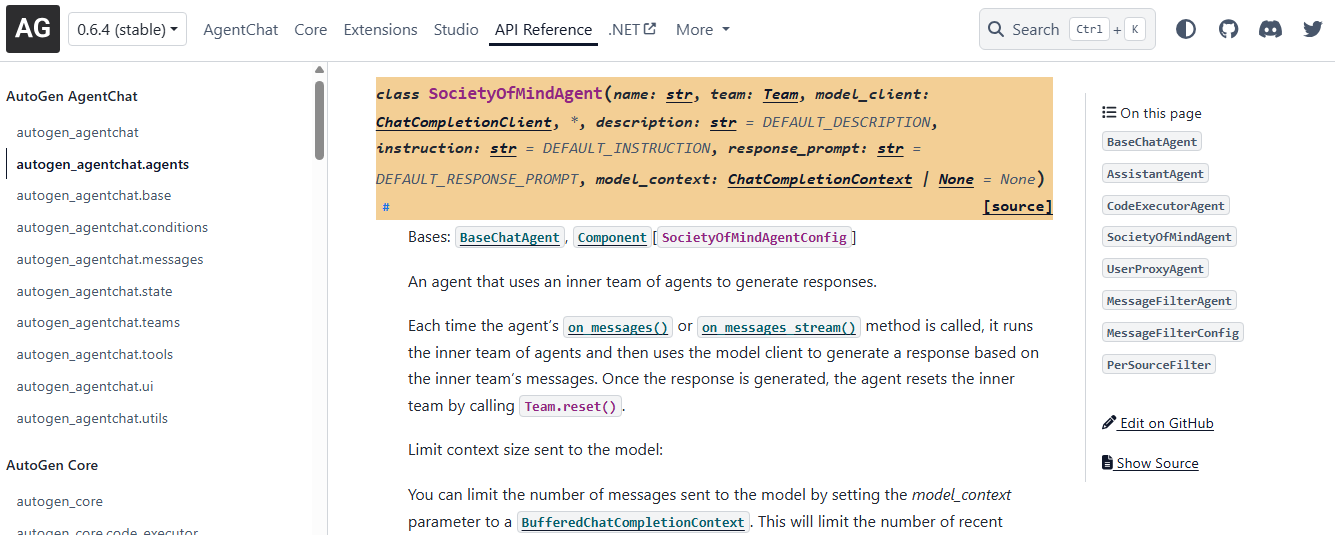

In [11]:
society_of_mind_agent= SocietyOfMindAgent(
    name="society_of_mind", 
    team=inner_team, 
    model_client=model_client,
    response_prompt='Output a standalone response to the original request under 50 words, without mentioning any of the intermediate discussion.'
)

#### Assistant Agent-3

In [13]:
agent3= AssistantAgent(
        name="assistant3", 
        model_client=model_client, 
        system_message="Translate the text to Spanish under 50 words."
)

In [14]:
team= RoundRobinGroupChat(
    [society_of_mind_agent, agent3], 
    max_turns=2
)

In [ ]:
stream= team.run_stream(task="Write a short story with a surprising ending under 50 words.")
await Console(stream)

---------- TextMessage (user) ----------
Write a short story with a surprising ending under 50 words.
---------- TextMessage (assistant1) ----------
Every day, Lucy whispered secrets to the ocean, believing her worries vanished within waves. One dawn, a bottle washed ashore, containing a note: “I hear you. Keep talking.” Startled, she turned to see a lone figure waving from a distant island, her mirror image.
---------- TextMessage (assistant2) ----------
APPROVE
---------- TextMessage (society_of_mind) ----------
Every day, Lucy whispered secrets to the ocean. One day, a bottle with a note washed ashore: “I hear you. Keep talking.” Startled, she saw a lone figure waving from a distant island—her mirror image.
---------- TextMessage (assistant3) ----------
Cada día, Lucy susurraba secretos al océano. Un día, una botella con una nota llegó a la orilla: "Te escucho. Sigue hablando". Sorprendida, vio una figura solitaria saludando desde una isla lejana: su imagen reflejada.


TaskResult(messages=[TextMessage(id='47a5bbaa-fe10-44f3-a258-fa05f9b72640', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 40, 65536, tzinfo=datetime.timezone.utc), content='Write a short story with a surprising ending under 50 words.', type='TextMessage'), TextMessage(id='f11654aa-c271-4bb6-9125-db4f917eab2c', source='assistant1', models_usage=RequestUsage(prompt_tokens=37, completion_tokens=58), metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 42, 435249, tzinfo=datetime.timezone.utc), content='Every day, Lucy whispered secrets to the ocean, believing her worries vanished within waves. One dawn, a bottle washed ashore, containing a note: “I hear you. Keep talking.” Startled, she turned to see a lone figure waving from a distant island, her mirror image.', type='TextMessage'), TextMessage(id='d7952927-0188-4068-81cf-c07440a56eb0', source='assistant2', models_usage=RequestUsage(prompt_tokens=118, completion_tokens=3), metada

#### Structured Output

In [ ]:
TaskResult(messages=[
    TextMessage(id='47a5bbaa-fe10-44f3-a258-fa05f9b72640', 
    source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 40, 65536, tzinfo=datetime.timezone.utc), 
    content='Write a short story with a surprising ending under 50 words.', type='TextMessage'), 
    
    TextMessage(id='f11654aa-c271-4bb6-9125-db4f917eab2c', 
    source='assistant1', models_usage=RequestUsage(prompt_tokens=37, completion_tokens=58), metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 42, 435249, tzinfo=datetime.timezone.utc), 
    content='Every day, Lucy whispered secrets to the ocean, believing her worries vanished within waves. One dawn, a bottle washed ashore, containing a note: “I hear you. Keep talking.” Startled, she turned to see a lone figure waving from a distant island, her mirror image.', type='TextMessage'), 
    
    TextMessage(id='d7952927-0188-4068-81cf-c07440a56eb0', 
    source='assistant2', models_usage=RequestUsage(prompt_tokens=118, completion_tokens=3), metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 43, 583732, tzinfo=datetime.timezone.utc), 
    content='APPROVE', type='TextMessage'), 
    
    TextMessage(id='98f128bc-d0ea-4eab-ba82-bc2e0d12bb74', 
    source='society_of_mind', models_usage=RequestUsage(prompt_tokens=135, completion_tokens=48), metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 45, 188402, tzinfo=datetime.timezone.utc), 
    content='Every day, Lucy whispered secrets to the ocean. One day, a bottle with a note washed ashore: “I hear you. Keep talking.” Startled, she saw a lone figure waving from a distant island—her mirror image.', type='TextMessage'), 
    
    TextMessage(id='293447b9-96bc-44d2-a93e-931240c90841', 
    source='assistant3', models_usage=RequestUsage(prompt_tokens=93, completion_tokens=56), metadata={}, created_at=datetime.datetime(2025, 7, 27, 18, 2, 47, 70491, tzinfo=datetime.timezone.utc), 
    content='Cada día, Lucy susurraba secretos al océano. Un día, una botella con una nota llegó a la orilla: "Te escucho. Sigue hablando". Sorprendida, vio una figura solitaria saludando desde una isla lejana: su imagen reflejada.', type='TextMessage')], 

stop_reason='Maximum number of turns 2 reached.')

In [18]:
# Reset team

await team.reset()

In [19]:
async def main() -> None:
    # Agent-1
    agent1= AssistantAgent(
        name="assistant1", 
        model_client=model_client, 
        system_message="You are a writer, write well under 50 words."
    )

    # Agent-2
    agent2= AssistantAgent(
            "assistant2",
            model_client=model_client,
            system_message="You are an editor, provide critical feedback under 50 words. Respond with 'APPROVE' if the text addresses all feedbacks."
        )

    # Termination for inner team
    inner_termination= TextMentionTermination("APPROVE")

    # Define inner team by using Round Robin Group Chat
    inner_team= RoundRobinGroupChat(
        [agent1, agent2], 
        termination_condition=inner_termination
    )

    # Define Society of mind
    society_of_mind_agent= SocietyOfMindAgent(
        name="society_of_mind", 
        team=inner_team, 
        model_client=model_client,
        response_prompt='Output a standalone response to the original request under 50 words, without mentioning any of the intermediate discussion.'
    )

    # Agent-3
    agent3= AssistantAgent(
            name="assistant3", 
            model_client=model_client, 
            system_message="Translate the text to Spanish under 50 words."
    )

    # Define outer team by using Round Robin Group Chat where maximum turns=2
    team= RoundRobinGroupChat(
        [society_of_mind_agent, agent3], 
        max_turns=2
    )

    # Run Stream
    stream= team.run_stream(task="Write a short story with a surprising ending under 50 words.")
    await Console(stream)

await (main())


---------- TextMessage (user) ----------
Write a short story with a surprising ending under 50 words.
---------- TextMessage (assistant1) ----------
Ella cherished the old locket, believing it held a photo of her late grandmother. One day, curiosity got the best of her. She opened it to find not a photo, but a hidden message: "Look beneath the tree." Digging there, Ella unearthed a box of forgotten family treasures.
---------- TextMessage (assistant2) ----------
APPROVE
---------- TextMessage (society_of_mind) ----------
Ella discovered a hidden message in her cherished locket, directing her to dig beneath a tree. There, she unearthed a box filled with forgotten family treasures, revealing a new connection to her ancestral past.
---------- TextMessage (assistant3) ----------
Ella descubrió un mensaje oculto en su querido relicario que la llevó a excavar bajo un árbol. Allí desenterró una caja llena de tesoros familiares olvidados, revelando una nueva conexión con su pasado ancestral.


In [20]:
async def main() -> None:
    # Agent-1
    agent1= AssistantAgent(
        name="assistant1", 
        model_client=model_client, 
        system_message="You are a writer, write well under 50 words."
    )

    # Agent-2
    agent2= AssistantAgent(
            "assistant2",
            model_client=model_client,
            system_message="You are an editor, provide critical feedback under 50 words. Respond with 'APPROVE' if the text addresses all feedbacks."
        )

    # Termination for inner team
    inner_termination= TextMentionTermination("APPROVE")

    # Define inner team by using Round Robin Group Chat
    inner_team= RoundRobinGroupChat(
        [agent1, agent2], 
        termination_condition=inner_termination
    )

    # Define Society of mind
    society_of_mind_agent= SocietyOfMindAgent(
        name="society_of_mind", 
        team=inner_team, 
        model_client=model_client,
        response_prompt='Output a standalone response to the original request under 50 words, without mentioning any of the intermediate discussion.'
    )

    # Agent-3
    agent3= AssistantAgent(
            name="assistant3", 
            model_client=model_client, 
            system_message="Translate the text to Spanish under 50 words."
    )

    # Define outer team by using Round Robin Group Chat where maximum turns=2
    team= RoundRobinGroupChat(
        [society_of_mind_agent, agent3], 
        max_turns=5
    )

    # Run Stream
    stream= team.run_stream(task="Write a short story with a surprising ending under 50 words.")
    await Console(stream)

await (main())

---------- TextMessage (user) ----------
Write a short story with a surprising ending under 50 words.
---------- TextMessage (assistant1) ----------
In the quiet library, Anna found a diary detailing magical adventures. She wished for excitement, and suddenly found herself flying. Elated, she turned, realizing her small town was gone. The library and her hometown were inside the book. Now, she could only visit her world through its pages.
---------- TextMessage (assistant2) ----------
While the story features an intriguing twist, the concept can be articulated more clearly by emphasizing the transition from reality to the world within the book. It feels cramped trying to establish the setting, wish fulfillment, and twist in the limited word count. Consider focusing on a single aspect.
---------- TextMessage (assistant1) ----------
In the quiet library, Anna found a diary detailing magical adventures. She wished for excitement, and suddenly she was flying. Elated, she turned, realizing 